# KNN + HAC

In [4]:
import numpy as np

In [5]:
train_data = np.load("./data/ebm_nlp_2_00/processed/participants_vectors.npz", allow_pickle=True)
X_train = train_data['X']
y_train = train_data['y']
train_tokens = train_data['tokens']

test_data = np.load("./data/ebm_nlp_2_00/processed/participants_vectors_test.npz", allow_pickle=True)
X_test = test_data['X']
y_test = test_data['y']
test_tokens = test_data['tokens']

              precision    recall  f1-score   support

           B       0.50      0.08      0.13        39
           I       0.43      0.03      0.06       100
           O       0.93      1.00      0.96      1861

    accuracy                           0.93      2000
   macro avg       0.62      0.37      0.38      2000
weighted avg       0.90      0.93      0.90      2000



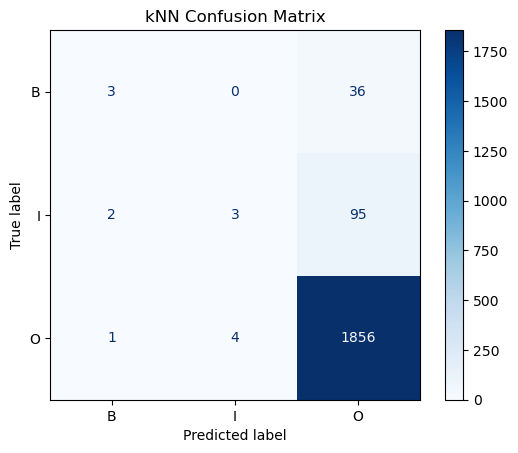

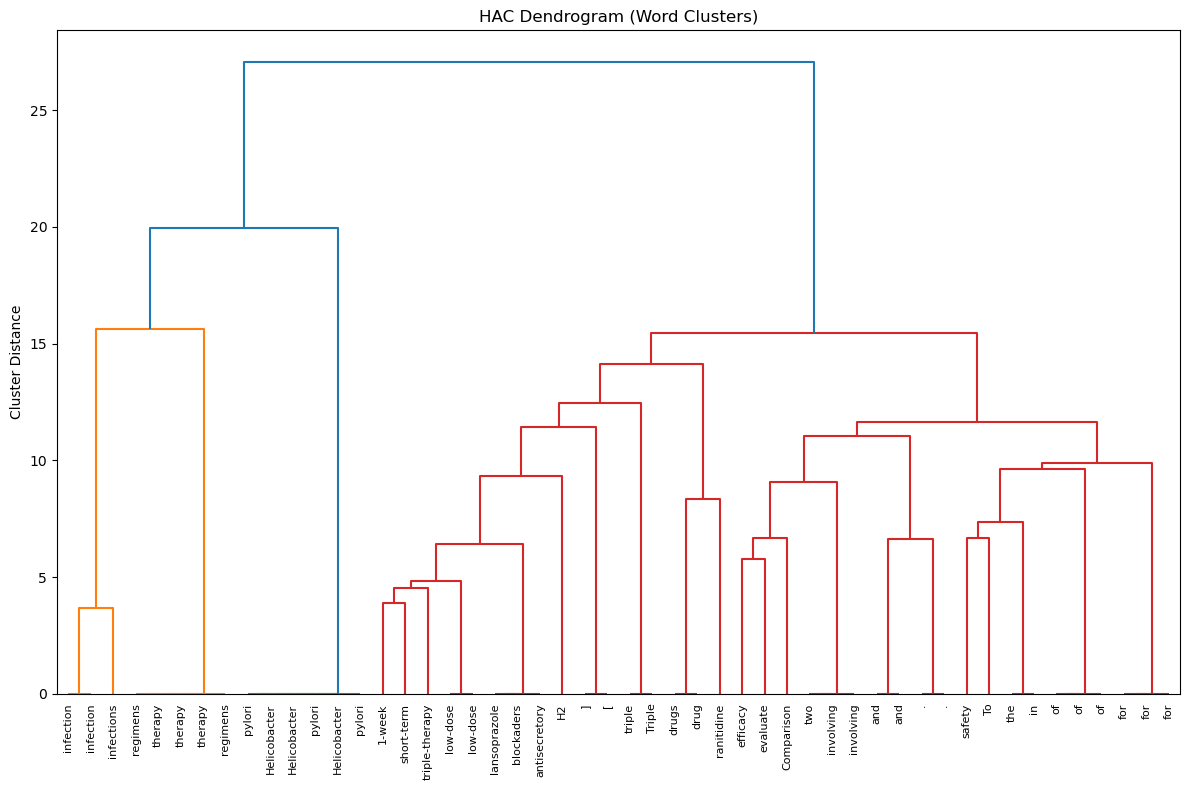

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.cluster.hierarchy import dendrogram, linkage


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train[:20000], y_train_enc[:20000])

knn_preds = knn.predict(X_test[:2000]
                       )
print(classification_report(y_test_enc[:2000], knn_preds, target_names=le.classes_))

cm = confusion_matrix(y_test_enc[:2000], knn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("kNN Confusion Matrix")
plt.show()

hac_sample_size = 50
hac = AgglomerativeClustering(n_clusters=3)
hac_clusters = hac.fit_predict(X_train[:hac_sample_size])


X_hac = X_train[:hac_sample_size]
tokens_hac = train_tokens[:hac_sample_size]
linked = linkage(X_hac, 'ward')

plt.figure(figsize=(12, 8))
dendrogram(linked,
            orientation='top',
            labels=tokens_hac,
            distance_sort='descending',
            show_leaf_counts=True)

plt.title("HAC Dendrogram (Word Clusters)")
plt.xticks(rotation=90)
plt.ylabel("Cluster Distance")
plt.tight_layout()
plt.show()